In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [11]:
from google.colab import files
uploaded=files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


## Data Loading and Initial Inspection of `Mall_Customers.csv`

In [12]:
df_mall = pd.read_csv('Mall_Customers.csv')

print("First 5 rows of the Mall Customers dataset:")
display(df_mall.head())

print("\nDataFrame Info for Mall Customers dataset:")
df_mall.info()

print("\nMissing values in each column for Mall Customers dataset:")
display(df_mall.isnull().sum())

First 5 rows of the Mall Customers dataset:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



DataFrame Info for Mall Customers dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values in each column for Mall Customers dataset:


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Exploratory Data Analysis (EDA) for `Mall_Customers.csv`

Let's analyze the distribution of numerical features and the count of categorical features.

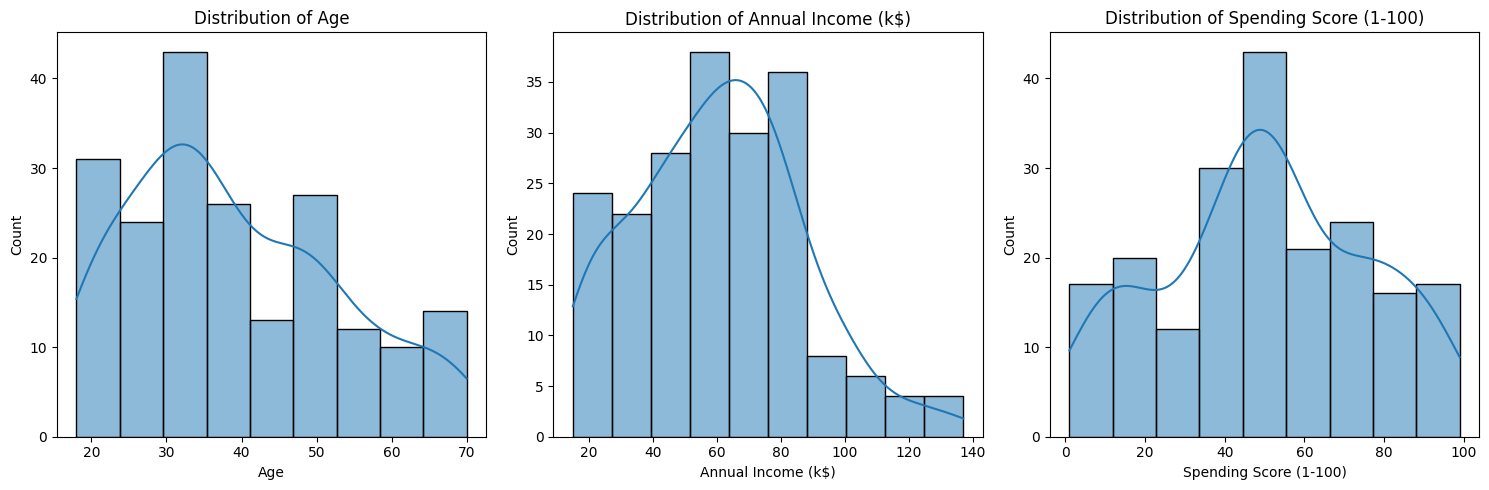

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_mall['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df_mall['Annual Income (k$)'], kde=True)
plt.title('Distribution of Annual Income (k$)')

plt.subplot(1, 3, 3)
sns.histplot(df_mall['Spending Score (1-100)'], kde=True)
plt.title('Distribution of Spending Score (1-100)')

plt.tight_layout()
plt.show()

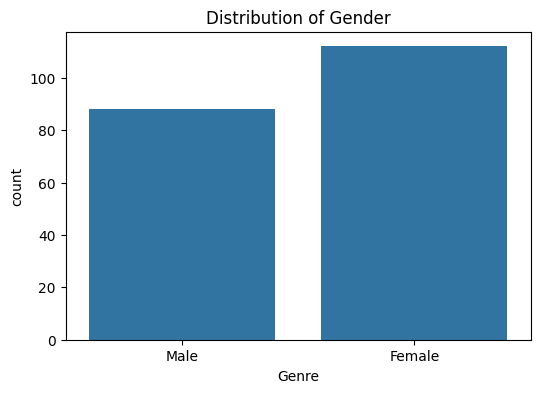

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Genre', data=df_mall)
plt.title('Distribution of Gender')
plt.show()

## Prepare Data for Hierarchical Clustering

For clustering, we'll focus on 'Annual Income (k$)' and 'Spending Score (1-100)'. We also need to scale these features.

In [15]:
from sklearn.preprocessing import StandardScaler

X = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_mall_scaled = pd.DataFrame(X_scaled, columns=['Annual Income (k$)_Scaled', 'Spending Score (1-100)_Scaled'])
display(df_mall_scaled.head())

,Annual Income (k$)_Scaled,Spending Score (1-100)_Scaled
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## Hierarchical Clustering

First, we'll use a dendrogram to help determine the optimal number of clusters.

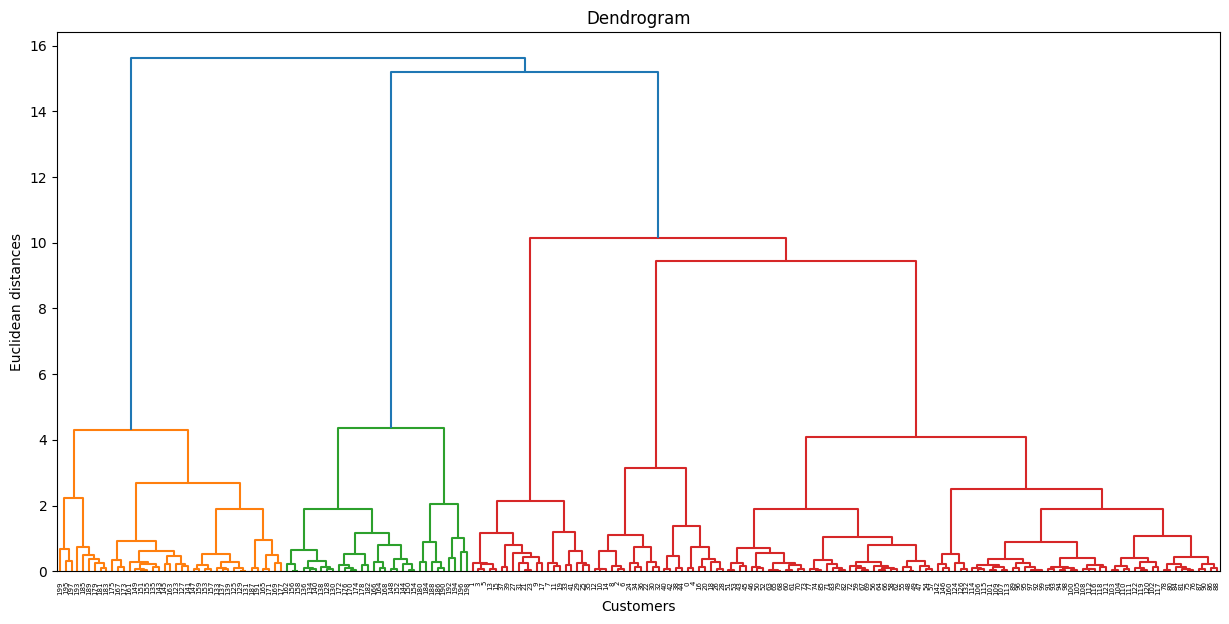

In [16]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15, 7))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [20]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 5 clusters
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X_scaled)

df_mall['Cluster'] = y_hc

print("First 5 rows with assigned clusters:")
display(df_mall.head())

print("\nCluster distribution:")
display(df_mall['Cluster'].value_counts())

First 5 rows with assigned clusters:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4



Cluster distribution:


,count
Cluster,
2,85
1,39
0,32
4,23
3,21


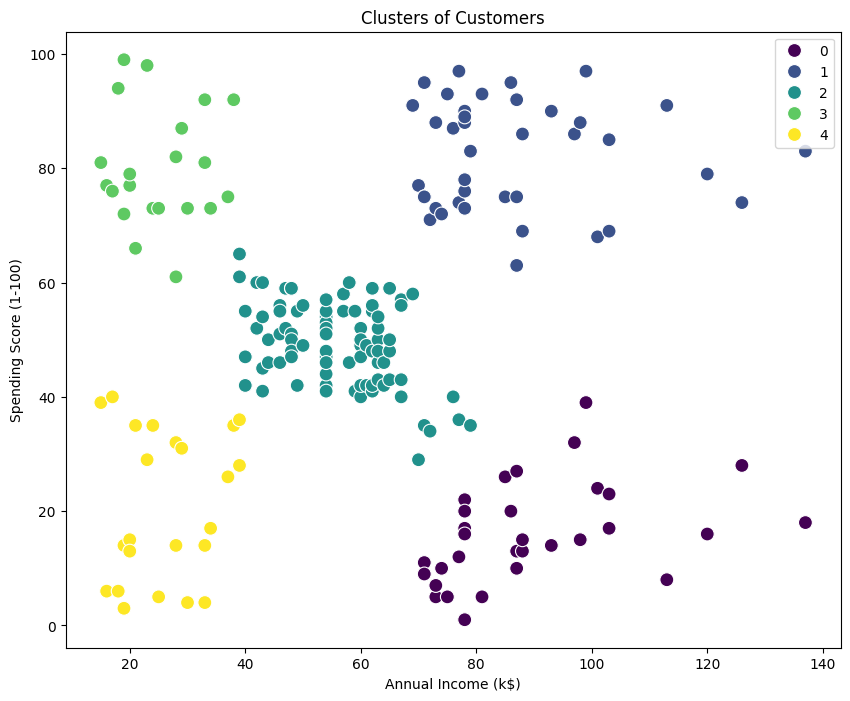

In [23]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_mall, palette='viridis', s=100)
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()